In [48]:
import pandas as pd
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [49]:
funnel = pd.read_csv('../Soyun_EDA/funnel_instance.csv')#EDA 코드 돌리고 나온 파일로 하심 됩니다
full = pd.read_csv('../Soyun_EDA/final_eda.csv')

In [50]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'offer_duration',
       'offer_type_port', 'duration_hours', 'within_duration', 'was_viewed',
       'was_completed'],
      dtype='str')

In [51]:
# 불필요 컬럼 제거
funnel = funnel.drop(columns=['offer_type_port', 'offer_duration', 'duration_hours'], errors='ignore')

print(funnel.columns)

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'within_duration',
       'was_viewed', 'was_completed'],
      dtype='str')


In [52]:
cust_attr = (
    full[['customer_id', 'join_year', 'join_month', 'join_year_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')

In [ ]:
# offer_id가 unique여야 하므로 validate='m:1' 검사
portfolio = (
    full[['offer_id', 'difficulty', 'reward', 'duration', 'offer_type']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
funnel = funnel.merge(portfolio, on='offer_id', how='left', validate='m:1')

# customer_id가 unique여야 하므로 validate='m:1' 검사
cust_attr = ( # distinct customer_id
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_year_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')
funnel.head(10)

,customer_id,offer_id,t_received,offer_type_x,instance_id,duration_x,t_expire,t_viewed,last_viewed,view_count,...,reward,duration_y,offer_type_y,gender,age_group,income_group,join_year_y,join_month_y,join_year_month_y,join_cohort_y
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,...,2.0,7.0,discount,M,30대,5-7.5만,2017,4,2017-04,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,...,0.0,4.0,informational,M,30대,5-7.5만,2017,4,2017-04,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,...,0.0,3.0,informational,M,30대,5-7.5만,2017,4,2017-04,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,...,5.0,5.0,bogo,M,30대,5-7.5만,2017,4,2017-04,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,...,2.0,10.0,discount,M,30대,5-7.5만,2017,4,2017-04,2017-04
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,...,5.0,5.0,bogo,Unknown,누락,누락,2018,4,2018-04,2018-04
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,...,5.0,5.0,bogo,Unknown,누락,누락,2018,4,2018-04,2018-04
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,408,discount,1,10.0,648.0,432.0,432.0,1.0,...,5.0,10.0,discount,O,40대,5-7.5만,2018,1,2018-01,2018-01
8,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,168,discount,1,7.0,336.0,186.0,186.0,1.0,...,3.0,7.0,discount,O,40대,5-7.5만,2018,1,2018-01,2018-01
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,...,0.0,4.0,informational,O,40대,5-7.5만,2018,1,2018-01,2018-01


In [54]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type_x', 'instance_id',
       'duration_x', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'within_duration',
       'was_viewed', 'was_completed', 'join_year_x', 'join_month_x',
       'join_year_month_x', 'join_cohort_x', 'difficulty', 'reward',
       'duration_y', 'offer_type_y', 'gender', 'age_group', 'income_group',
       'join_year_y', 'join_month_y', 'join_year_month_y', 'join_cohort_y'],
      dtype='str')

In [55]:
# _x suffix 제거
funnel.columns = funnel.columns.str.replace(r'_x$', '', regex=True)

# _y 컬럼 제거
funnel = funnel.drop(columns=[c for c in funnel.columns if c.endswith('_y')], errors='ignore')

In [56]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'within_duration',
       'was_viewed', 'was_completed', 'join_year', 'join_month',
       'join_year_month', 'join_cohort', 'difficulty', 'reward', 'gender',
       'age_group', 'income_group'],
      dtype='str')

In [57]:
from scipy import stats

bogo_gap = funnel.loc[
    (funnel['offer_type'] == 'bogo') & (funnel['gap_to_complete'].notna()),
    'gap_to_complete'
]
disc_gap = funnel.loc[
    (funnel['offer_type'] == 'discount') & (funnel['gap_to_complete'].notna()),
    'gap_to_complete'
]

print(f"bogo     완료 건수: {len(bogo_gap):,}  중앙값: {bogo_gap.median()/24:.1f}일  평균: {bogo_gap.mean()/24:.1f}일")
print(f"discount 완료 건수: {len(disc_gap):,}  중앙값: {disc_gap.median()/24:.1f}일  평균: {disc_gap.mean()/24:.1f}일")

bogo_sample = bogo_gap.sample(min(5000, len(bogo_gap)), random_state=42)
disc_sample = disc_gap.sample(min(5000, len(disc_gap)), random_state=42)

_, p_b = stats.shapiro(bogo_sample)
_, p_d = stats.shapiro(disc_sample)

print(f"\n정규성 검정 (Shapiro-Wilk, 최대 5000 샘플)")
print(f"bogo p={p_b:.4f} / discount p={p_d:.4f}")
print("→ 비정규 분포 가정, Mann-Whitney U 사용")

u_stat, p_val = stats.mannwhitneyu(bogo_gap, disc_gap, alternative='two-sided')

print(f"\nMann-Whitney U test")
print(f"U={u_stat:.0f},  p={p_val:.2e}")

if p_val < 0.05:
    print(f"→ p < 0.05: bogo가 discount보다 {(disc_gap.median() - bogo_gap.median())/24:.1f}일 빠르게 완료됨")
else:
    print("→ p >= 0.05: 유의미한 차이 없음")

n1, n2 = len(bogo_gap), len(disc_gap)
r = 1 - (2 * u_stat) / (n1 * n2)

print(f"효과 크기 (rank-biserial r) = {r:.3f}")
print(f"→ {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큼 (|r|≥0.3)'}")

bogo     완료 건수: 15,501  중앙값: 1.8일  평균: 2.1일
discount 완료 건수: 17,600  중앙값: 2.5일  평균: 3.0일

정규성 검정 (Shapiro-Wilk, 최대 5000 샘플)
bogo p=0.0000 / discount p=0.0000
→ 비정규 분포 가정, Mann-Whitney U 사용

Mann-Whitney U test
U=107644868,  p=1.37e-241
→ p < 0.05: bogo가 discount보다 0.8일 빠르게 완료됨
효과 크기 (rank-biserial r) = 0.211
→ 중간 (0.1≤|r|<0.3)


In [58]:
total_received  = len(funnel)
total_viewed    = funnel['was_viewed'].sum()
total_completed = funnel['was_completed'].sum()
aware_completed = ((funnel['was_completed'] == 1) & (funnel['completed_without_view'] == 0)).sum()

view_rate        = total_viewed / total_received
complete_rate    = total_completed / total_received
view_to_complete = aware_completed / total_viewed if total_viewed > 0 else 0

print(f"수신 → 열람 전환율:          {view_rate*100:.1f}%")
print(f"수신 → 완료 전환율:          {complete_rate*100:.1f}%")
print(f"열람 → 완료 전환율:          {view_to_complete*100:.1f}%  (열람 후 완료 기준, 미인지 완료 제외)")
print(f"※ 미인지 완료 포함 시:       {total_completed / total_viewed * 100:.1f}%")

수신 → 열람 전환율:          74.2%
수신 → 완료 전환율:          43.4%
열람 → 완료 전환율:          48.4%  (열람 후 완료 기준, 미인지 완료 제외)
※ 미인지 완료 포함 시:       58.5%


In [59]:
not_viewed = funnel[funnel['was_viewed'] == 0]
print(f"미열람 오퍼: {len(not_viewed):,}건  ({len(not_viewed)/total_received*100:.1f}%)")

print("\n[ 연령대 ]")
nv_age  = not_viewed['age_group'].value_counts(normalize=True) * 100
all_age = funnel['age_group'].value_counts(normalize=True) * 100
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상', '누락']
for a in age_order:
    nv = nv_age.get(a, 0); al = all_age.get(a, 0); diff = nv - al
    print(f"  {a:<8}  미열람 {nv:.1f}%  전체 {al:.1f}%  ({'+' if diff>0 else ''}{diff:.1f}%p)")

print("\n[ 소득 구간 ]")
nv_inc  = not_viewed['income_group'].value_counts(normalize=True) * 100
all_inc = funnel['income_group'].value_counts(normalize=True) * 100
for i in ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']:
    nv = nv_inc.get(i, 0); al = all_inc.get(i, 0); diff = nv - al
    print(f"  {i:<10}  미열람 {nv:.1f}%  전체 {al:.1f}%  ({'+' if diff>0 else ''}{diff:.1f}%p)")

print("\n[ 오퍼 유형별 미열람률 ]")
for otype in ['bogo', 'discount', 'informational']:
    ot = funnel[funnel['offer_type'] == otype]
    nv_rate = (ot['was_viewed'] == 0).mean() * 100
    print(f"  {otype:<15}  {nv_rate:.1f}%")

미열람 오퍼: 19,710건  (25.8%)

[ 연령대 ]
  20대 미만    미열람 1.4%  전체 1.2%  (+0.2%p)
  20대       미열람 10.1%  전체 8.1%  (+2.0%p)
  30대       미열람 10.2%  전체 9.0%  (+1.1%p)
  40대       미열람 11.6%  전체 13.5%  (-1.8%p)
  50대       미열람 21.0%  전체 20.8%  (+0.2%p)
  60대 이상    미열람 35.2%  전체 34.5%  (+0.7%p)
  누락        미열람 10.4%  전체 12.8%  (-2.4%p)

[ 소득 구간 ]
  누락          미열람 10.4%  전체 12.8%  (-2.4%p)
  5만 미만       미열람 28.4%  전체 22.2%  (+6.2%p)
  5-7.5만      미열람 34.8%  전체 38.0%  (-3.2%p)
  7.5-10만     미열람 17.6%  전체 20.5%  (-2.9%p)
  10만 이상      미열람 8.8%  전체 6.4%  (+2.4%p)

[ 오퍼 유형별 미열람률 ]
  bogo             17.2%
  discount         30.0%
  informational    34.7%


In [60]:
unaware = funnel[funnel['completed_without_view'] == 1]
aware   = funnel[(funnel['was_completed'] == 1) & (funnel['completed_without_view'] == 0)]

print(f"정상 퍼널 완료 (열람→완료): {len(aware):,}건  ({len(aware)/(len(aware)+len(unaware))*100:.1f}%)")
print(f"미인지 완료 (열람 없이 완료): {len(unaware):,}건  ({len(unaware)/(len(aware)+len(unaware))*100:.1f}%)")

print("\n[ 소득 구간 ]")
uw_inc = unaware['income_group'].value_counts(normalize=True) * 100
aw_inc = aware['income_group'].value_counts(normalize=True) * 100
for i in ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']:
    uw = uw_inc.get(i, 0); aw = aw_inc.get(i, 0); diff = uw - aw
    print(f"  {i:<10}  미인지 {uw:.1f}%  정상 {aw:.1f}%  ({'+' if diff>0 else ''}{diff:.1f}%p)")

tx = full[full['event'] == 'transaction'][['customer_id', 'time', 'amount']]

def get_nearby_tx(completed_df, tx_df, complete_time_col='t_completed', window=24):
    # 인스턴스 단위 (customer_id + t_completed 키)로 완료 전후 거래금액 집계
    inst = completed_df[['customer_id', complete_time_col]].copy()
    inst = inst.reset_index().rename(columns={'index': '_inst_key'})
    merged = inst.merge(
        tx_df.rename(columns={'time': 'tx_time', 'amount': 'tx_amount'}),
        on='customer_id', how='left'
    )
    merged = merged[
        (merged['tx_time'] >= merged[complete_time_col] - window) &
        (merged['tx_time'] <= merged[complete_time_col] + window)
    ]
    return merged.groupby('_inst_key')['tx_amount'].mean()

uw_tx = get_nearby_tx(unaware, tx)
aw_tx = get_nearby_tx(aware, tx)

print(f"\n완료 전후 24시간 내 평균 거래금액:")
print(f"  미인지 완료: ${uw_tx.mean():.2f}")
print(f"  정상 퍼널:   ${aw_tx.mean():.2f}")

u2, p2 = stats.mannwhitneyu(uw_tx.dropna(), aw_tx.dropna(), alternative='two-sided')
print(f"\nMann-Whitney U test: p={p2:.4f}")
print(f"→ {'유의미한 차이 있음' if p2 < 0.05 else '유의미한 차이 없음'}")

정상 퍼널 완료 (열람→완료): 27,372건  (82.7%)
미인지 완료 (열람 없이 완료): 5,729건  (17.3%)

[ 소득 구간 ]
  누락          미인지 2.0%  정상 3.6%  (-1.6%p)
  5만 미만       미인지 21.8%  정상 17.2%  (+4.5%p)
  5-7.5만      미인지 35.2%  정상 42.8%  (-7.7%p)
  7.5-10만     미인지 26.9%  정상 28.2%  (-1.3%p)
  10만 이상      미인지 14.1%  정상 8.1%  (+6.1%p)

완료 전후 24시간 내 평균 거래금액:
  미인지 완료: $20.77
  정상 퍼널:   $19.55

Mann-Whitney U test: p=0.0000
→ 유의미한 차이 있음


In [61]:
info_received = funnel[funnel['offer_type']=='informational'][['customer_id','offer_id','t_received','duration']].copy()
info_received['t_expire'] = info_received['t_received'] + info_received['duration'] * 24

info_tx = info_received.merge(tx.rename(columns={'time':'tx_time'}), on='customer_id', how='left')
info_tx['within_window'] = (
    (info_tx['tx_time'] >= info_tx['t_received']) &
    (info_tx['tx_time'] <= info_tx['t_expire'])
)

# t_received로 인스턴스 구분 (customer_id+offer_id만 쓰면 중복 수신 건 collapse됨)
info_linked = (
    info_tx[info_tx['within_window']]
    .groupby(['customer_id', 'offer_id', 't_received'])
    .size().reset_index()
)
info_linked_cnt = len(info_linked)
info_total = len(info_received)
link_rate = info_linked_cnt / info_total * 100

print(f"informational 수신: {info_total:,}건  /  유효기간 내 거래 발생: {info_linked_cnt:,}건  ({link_rate:.1f}%)")

bogo_cr = funnel[funnel['offer_type']=='bogo']['was_completed'].mean() * 100
disc_cr = funnel[funnel['offer_type']=='discount']['was_completed'].mean() * 100
print(f"\nbogo 완료율:           {bogo_cr:.1f}%")
print(f"discount 완료율:       {disc_cr:.1f}%")
print(f"informational 연결률:  {link_rate:.1f}%")
print("※ informational 연결률 = 유효기간 내 거래 발생 여부, bogo/discount = offer completed 이벤트 기준")

informational 수신: 15,235건  /  유효기간 내 거래 발생: 9,483건  (62.2%)

bogo 완료율:           50.8%
discount 완료율:       57.6%
informational 연결률:  62.2%
※ informational 연결률 = 유효기간 내 거래 발생 여부, bogo/discount = offer completed 이벤트 기준


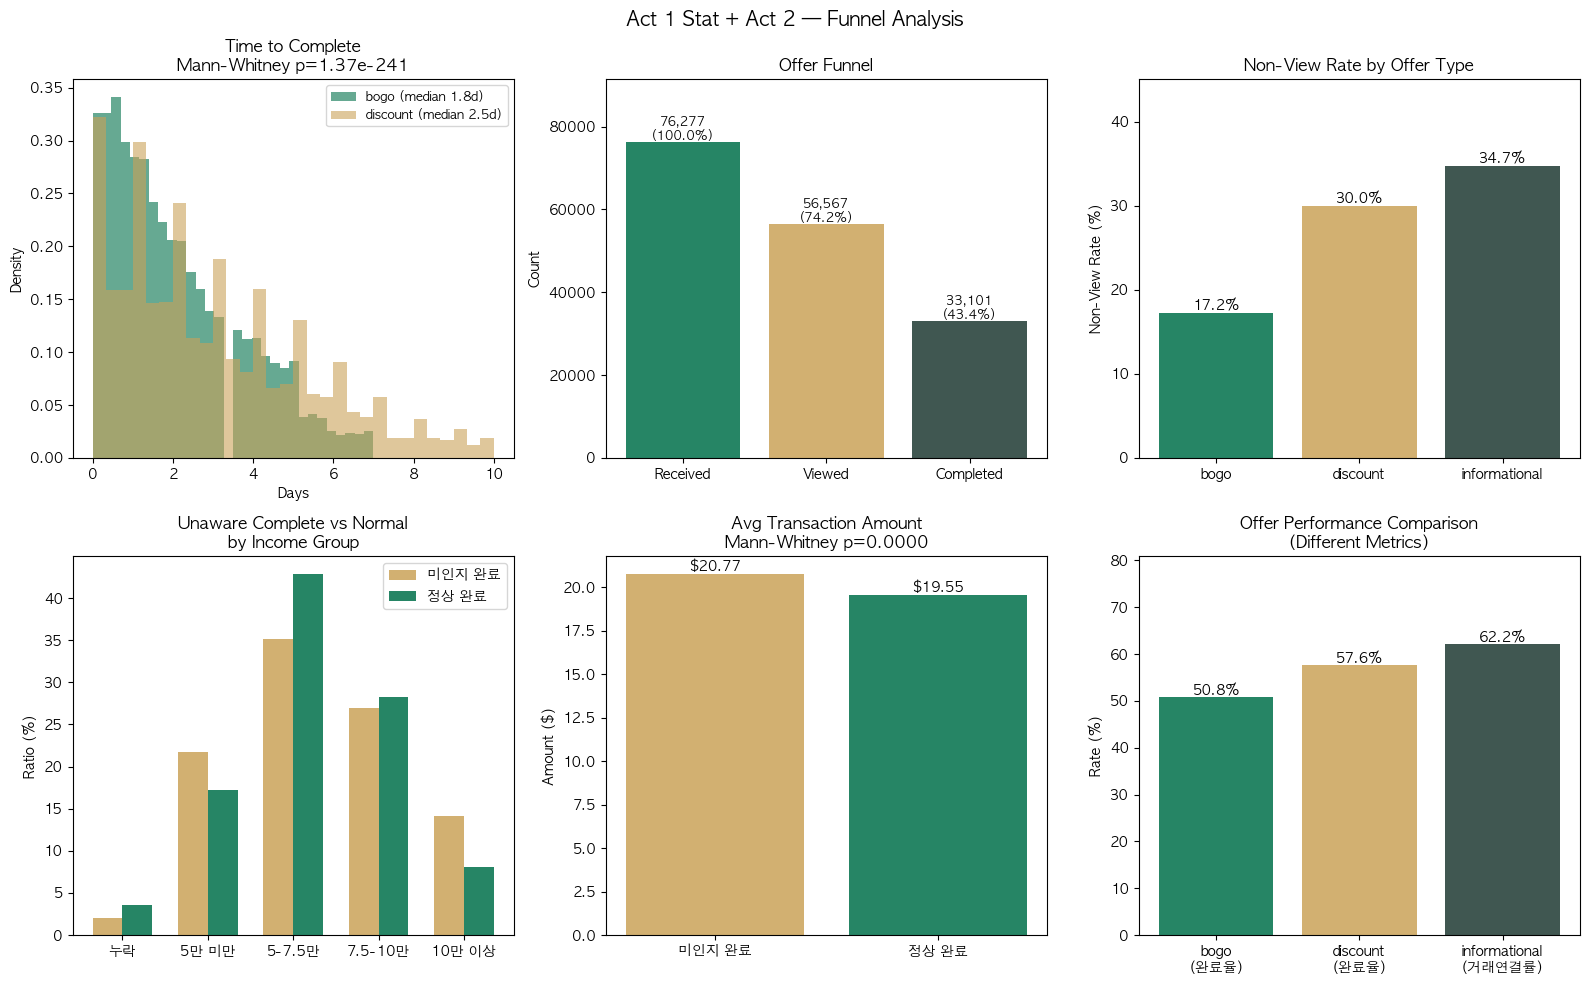

In [62]:
# stage2 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Act 1 Stat + Act 2 — Funnel Analysis', fontsize=14, fontweight='bold')

colors = ['#00704A', '#CBA258', '#1E3932', '#D4E9E2', '#006241', '#F2C75C']

# 차트 1: bogo vs discount 반응 시간 분포 (통계)
ax1 = axes[0, 0]
b_plot = (bogo_gap[bogo_gap <= 240] / 24)
d_plot = (disc_gap[disc_gap <= 240] / 24)
ax1.hist(b_plot, bins=30, alpha=0.6, color='#00704A',
         label=f'bogo (median {bogo_gap.median()/24:.1f}d)', density=True)
ax1.hist(d_plot, bins=30, alpha=0.6, color='#CBA258',
         label=f'discount (median {disc_gap.median()/24:.1f}d)', density=True)
ax1.set_title(f'Time to Complete\nMann-Whitney p={p_val:.2e}', fontweight='bold')
ax1.set_xlabel('Days')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)

# 차트 2: 퍼널 단계별 수치
ax2 = axes[0, 1]
stages = ['Received', 'Viewed', 'Completed']
vals = [total_received, total_viewed, total_completed]
bar_colors = ['#00704A', '#CBA258', '#1E3932']
bars = ax2.bar(stages, vals, color=bar_colors, alpha=0.85)
for bar, v, pct in zip(bars, vals, [100, total_viewed/total_received*100, total_completed/total_received*100]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)
ax2.set_title('Offer Funnel', fontweight='bold')
ax2.set_ylabel('Count')
ax2.set_ylim(0, max(vals) * 1.2)

# 차트 3: 오퍼 유형별 미열람률
ax3 = axes[0, 2]
nv_rates = []
otypes = ['bogo', 'discount', 'informational']
for ot in otypes:
    r = (funnel[funnel['offer_type'] == ot]['was_viewed'] == 0).mean() * 100
    nv_rates.append(r)
bars3 = ax3.bar(otypes, nv_rates, color=['#00704A', '#CBA258', '#1E3932'], alpha=0.85)
for bar, v in zip(bars3, nv_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
ax3.set_title('Non-View Rate by Offer Type', fontweight='bold')
ax3.set_ylabel('Non-View Rate (%)')
ax3.set_ylim(0, max(nv_rates) * 1.3)

# 차트 4: 미인지 완료 vs 정상 완료 소득 구간
ax4 = axes[1, 0]
inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']
uw_vals = [uw_inc.get(i, 0) for i in inc_order]
aw_vals = [aw_inc.get(i, 0) for i in inc_order]
x = range(len(inc_order))
w = 0.35
ax4.bar([i - w/2 for i in x], uw_vals, w, label='미인지 완료', color='#CBA258', alpha=0.85)
ax4.bar([i + w/2 for i in x], aw_vals, w, label='정상 완료', color='#00704A', alpha=0.85)
ax4.set_xticks(list(x))
ax4.set_xticklabels(inc_order)
ax4.set_title('Unaware Complete vs Normal\nby Income Group', fontweight='bold')
ax4.set_ylabel('Ratio (%)')
ax4.legend()

# 차트 5: 미인지 완료 vs 정상 완료 평균 거래금액
ax5 = axes[1, 1]
labels5 = ['미인지 완료', '정상 완료']
values5 = [uw_tx.mean(), aw_tx.mean()]
bars5 = ax5.bar(labels5, values5, color=['#CBA258', '#00704A'], alpha=0.85)
for bar, v in zip(bars5, values5):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'${v:.2f}', ha='center', fontsize=10)
ax5.set_title(f'Avg Transaction Amount\nMann-Whitney p={p2:.4f}', fontweight='bold')
ax5.set_ylabel('Amount ($)')

# 차트 6: 오퍼 유형별 성과 비교 (완료율 vs 연결률)
ax6 = axes[1, 2]
labels6 = ['bogo\n(완료율)', 'discount\n(완료율)', 'informational\n(거래연결률)']
values6 = [bogo_cr, disc_cr, link_rate]
colors6 = ['#00704A', '#CBA258', '#1E3932']
bars6 = ax6.bar(labels6, values6, color=colors6, alpha=0.85)
for bar, v in zip(bars6, values6):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
ax6.set_title('Offer Performance Comparison\n(Different Metrics)', fontweight='bold')
ax6.set_ylabel('Rate (%)')
ax6.set_ylim(0, max(values6) * 1.3)

plt.tight_layout()
plt.show()